### Emotion Classification with RNNs, LSTMs & GRUs
Classifying text into 6 emotions (sadness, joy, love, anger, fear, surprise) by comparing plain recurrent models before building an Advanced Bidirectional GRU.

#### 1. Import Libraries
Import TensorFlow/Keras, HuggingFace Datasets, and evaluation tools.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

#dataset load
from datasets import load_dataset
import huggingface_hub

#### 2. Load Dataset
Load the dair-ai/emotion dataset from Hugging Face. https://huggingface.co/datasets/dair-ai/emotion

In [2]:
emotion_dataset = load_dataset("dair-ai/emotion", "split")

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [3]:
emotion_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [4]:
train_text = emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']

test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

In [5]:
label_names = emotion_dataset['train'].features['label'].names
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [6]:
df_train = pd.DataFrame(
    {
        'text' : train_text,
        'label' : [label_names[i] for i in train_label] #mapping   0=sadness, 1=joy
    }
)

df_test = pd.DataFrame(
    {
        'text' : test_text,
        'label' : [label_names[i] for i in test_label]
    }
)

In [7]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [8]:
df_test.head()

,text,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


#### 3. Exploratory Data Analysis (EDA)
Visualize class distribution across the 6 emotion labels.

In [9]:
df_train['label'].value_counts()

,count
label,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


<Axes: xlabel='label', ylabel='count'>

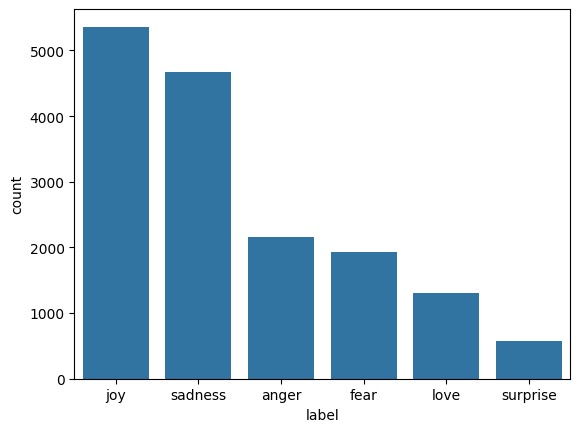

In [10]:
sns.countplot(x ='label', data=df_train, order = df_train['label'].value_counts().index)

#### 4. Data Preprocessing - Using NLP
Tokenize text, pad sequences to max length 50, and convert labels to NumPy arrays.

In [11]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
tokenizer = Tokenizer(num_words=max_words, oov_token='<unk>')  # OOV = Out Of Vocabulary(a word never come at the time of training is called) '<unk>' = a special token representing an unknown word
tokenizer.fit_on_texts(df_train['text'])

#Because of this tokenizer It will tell which word is morea and less important in your data base on nummbers
train_sequences = tokenizer.texts_to_sequences(df_train['text'])
test_sequences = tokenizer.texts_to_sequences(df_test['text'])

# Padding sequences  (so that input are samesize)
padded_train_sequences = pad_sequences(train_sequences, padding = 'post', maxlen=50, truncating='post') #truncating = remove extra numbers longer than maxlen
padded_test_sequences = pad_sequences(test_sequences, padding = 'post', maxlen=50, truncating='post')

#label convert into array
train_labels = np.array(train_label)
test_labels = np.array(test_label)

num_classes = len(np.unique(train_labels))

print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sequence Length: {padded_train_sequences.shape[1]}")

Vocabulary Size: 15213
Max Sequence Length: 50


#### 5. Shared Training Utilities
Compute balanced class weights to handle dataset skew and setup early stopping.

weight = total_sample/(num of classes * samples_in_that_class)

total_samples= 10000 ,
num of classes = 6

In [12]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(train_labels),
    y = train_labels
)

class_weights_dict = dict(enumerate(class_weights)) #converts the resulting array into a dictionary, for example:
class_weights_dict

{0: np.float64(0.5715102157451064),
 1: np.float64(0.49732686808404825),
 2: np.float64(2.044989775051125),
 3: np.float64(1.2351397251814111),
 4: np.float64(1.3766993632765445),
 5: np.float64(4.662004662004662)}

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    restore_best_weights = True
)

#### 6. Phase 1 — Plain Foundational Models
Train plain (non-bidirectional) Simple RNN, Standard LSTM, and Standard GRU models.


##### 6.1 Model 1 — Simple RNN
Plain unrolled Recurrent Neural Network.

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
    #Dense layer so the model has one output neuron for each possible category
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [15]:
rnn_model.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(padded_test_sequences, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.1614 - loss: 1.9296 - val_accuracy: 0.0865 - val_loss: 1.8069
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1541 - loss: 1.8037 - val_accuracy: 0.1645 - val_loss: 1.7805
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1567 - loss: 1.7961 - val_accuracy: 0.1000 - val_loss: 1.7934
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1504 - loss: 1.7833 - val_accuracy: 0.2105 - val_loss: 1.7655
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.1502 - loss: 1.7818 - val_accuracy: 0.1540 - val_loss: 1.7811
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1402 - loss: 1.8245 - val_accuracy: 0.0900 - val_loss: 1.7919
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1411 - loss: 1.8142 - val_accuracy: 0.2680 - val_loss: 1.7571
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1444 - loss: 1.8018 - val_ac

In [16]:
rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequences, test_labels)
print(f"Simple RNN Test Loss: {rnn_loss}")
print(f"Simple RNN Test Accuracy: {rnn_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2680 - loss: 1.7571
Simple RNN Test Loss: 1.7570596933364868
Simple RNN Test Accuracy: 0.2680000066757202


##### 6.2 Model 2 — Standard LSTM
Plain stacked Long Short-Term Memory network.

In [17]:
lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [18]:
lstm_model.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(padded_test_sequences, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.1514 - loss: 1.7954 - val_accuracy: 0.3435 - val_loss: 1.7753
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.1587 - loss: 1.7935 - val_accuracy: 0.0800 - val_loss: 1.8046
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1681 - loss: 1.7936 - val_accuracy: 0.1165 - val_loss: 1.8163


In [19]:
lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequences, test_labels)
print(f"LSTM Test Loss: {lstm_loss}")
print(f"LSTM Test Accuracy: {lstm_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3435 - loss: 1.7753
LSTM Test Loss: 1.7753030061721802
LSTM Test Accuracy: 0.3434999883174896


##### 6.3 Model 3 — Standard GRU
Plain stacked Gated Recurrent Unit network.

In [20]:
gru_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [21]:
gru_model.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(padded_test_sequences, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.1446 - loss: 1.7970 - val_accuracy: 0.0340 - val_loss: 1.7900
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.1653 - loss: 1.7951 - val_accuracy: 0.1365 - val_loss: 1.8106
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.1668 - loss: 1.7943 - val_accuracy: 0.3485 - val_loss: 1.7837


In [22]:
gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequences, test_labels)
print(f"GRU Test Loss: {gru_loss}")
print(f"GRU Test Accuracy: {gru_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0340 - loss: 1.7900
GRU Test Loss: 1.7900333404541016
GRU Test Accuracy: 0.03400000184774399


##### 6.4 Phase 1 Ranking & Selection
Rank foundational models to pick the best base cell for Phase 2.

In [23]:
results_df = pd.DataFrame({
    'Model': ['Simple RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
}).sort_values(by='Test Accuracy', ascending=False)
results_df

,Model,Test Loss,Test Accuracy
1,LSTM,1.775303,0.3435
0,Simple RNN,1.757060,0.2680
2,GRU,1.790033,0.0340


#### 7. Phase 2 — Advanced Bidirectional GRU
Enhance GRU with Bidirectional layers, 300D embeddings, and 0.5 dropout regularization.

##### 7.1 Model 4 — Advanced Stacked Bidirectional GRU

In [24]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length = 50),
    Bidirectional(GRU(units=128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(units=64)),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

BiGRU.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


##### Train & Evaluate Advanced Bidirectional GRU

In [25]:
BiGRU.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(padded_test_sequences, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5993 - loss: 0.9877 - val_accuracy: 0.8810 - val_loss: 0.3594
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9124 - loss: 0.2578 - val_accuracy: 0.9135 - val_loss: 0.2125
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9401 - loss: 0.1664 - val_accuracy: 0.9125 - val_loss: 0.2431
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9535 - loss: 0.1202 - val_accuracy: 0.9200 - val_loss: 0.2566
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9647 - loss: 0.0974 - val_accuracy: 0.9195 - val_loss: 0.2595


In [26]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequences, test_labels)
print(f"Bidirectional Test Loss: {BiGRU_loss}")
print(f"Bidirectional Test Accuracy: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9135 - loss: 0.2125
Bidirectional Test Loss: 0.2124936580657959
Bidirectional Test Accuracy: 0.9135000109672546


##### Practice
Model  — Advanced Stacked Bidirectional LSTM

In [27]:
from tensorflow.keras.layers import Bidirectional

BiLSTM = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length = 50),
    Bidirectional(LSTM(units=128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(LSTM(units=64)),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

BiLSTM.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [28]:
BiLSTM.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(padded_test_sequences, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.5811 - loss: 1.0432 - val_accuracy: 0.9005 - val_loss: 0.3193
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9112 - loss: 0.2822 - val_accuracy: 0.9120 - val_loss: 0.2705
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9402 - loss: 0.1719 - val_accuracy: 0.9010 - val_loss: 0.2704


In [29]:
BiLSTM_loss, BiLSTM_accuracy = BiLSTM.evaluate(padded_test_sequences, test_labels)
print(f"Bidirectional Test Loss: {BiLSTM_loss}")
print(f"Bidirectional Test Accuracy: {BiLSTM_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9005 - loss: 0.3193
Bidirectional Test Loss: 0.319307416677475
Bidirectional Test Accuracy: 0.9004999995231628


In [30]:
results_df = pd.DataFrame({
    'Model': ['BiLSTM', 'BiGRU'],
    'Test Loss': [BiLSTM_loss, BiGRU_loss],
    'Test Accuracy': [BiLSTM_accuracy, BiGRU_accuracy]
}).sort_values(by='Test Accuracy', ascending=False)
results_df

,Model,Test Loss,Test Accuracy
1,BiGRU,0.212494,0.9135
0,BiLSTM,0.319307,0.9005


#### 8. Overall Evaluation & Bias Analysis
Consolidate test metrics, plot raw & normalized confusion matrices, and analyze bias.

##### 8.1 Final Model Confusion Matrices (Raw Counts & Normalized %)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


<Axes: >

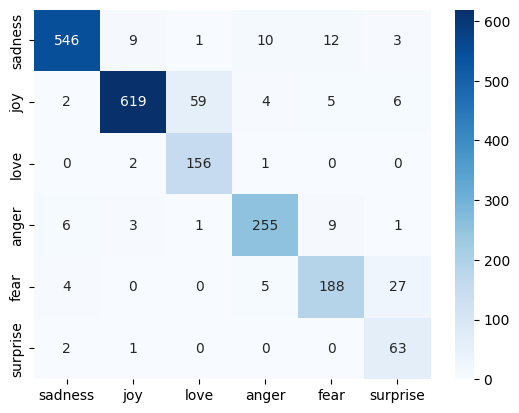

In [31]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = BiGRU.predict(padded_test_sequences)
BiGRU_predictions = np.argmax(BiGRU_predictions, axis=1) #higest probablity cosider as result

sns.heatmap(
    confusion_matrix(test_labels, BiGRU_predictions),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)

#### 9. Final Predictions
Test the winning model on unseen sample sentences.

In [32]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
    print(f'Text: {sample_texts[i]}\n Predicted Emotion : {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Text: I can't believe how happy I am right now, this is amazing!
 Predicted Emotion : fear
Text: I feel so alone and hopeless today.
 Predicted Emotion : sadness
Text: I am furious that they cancelled the trip at the last minute.
 Predicted Emotion : anger
Text: I feel terrified when walking down dark alleyways alone.
 Predicted Emotion : fear
Text: I was shocked and completely surprised by the unexpected gift!
 Predicted Emotion : surprise


#### 10. Save Model & Tokenizer
Export trained model and tokenizer artifacts for API deployment.

In [33]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True)

#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_model.keras'))

#Save the tokeniizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
    pickle.dump(tokenizer, file)